In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

In [2]:
os.chdir("/Users/kaiping/Desktop/olist_project/data") 
os.getcwd()

'/Users/kaiping/Desktop/olist_project/data'

In [3]:
df_translation = pd.read_csv("raw/product_category_name_translation.csv")
df_sellers     = pd.read_csv("raw/olist_sellers_dataset.csv")
df_products    = pd.read_csv("raw/olist_products_dataset.csv")
df_orders      = pd.read_csv("raw/olist_orders_dataset.csv")
df_order_reviews  = pd.read_csv("raw/olist_order_reviews_dataset.csv")
df_order_payments = pd.read_csv("raw/olist_order_payments_dataset.csv")
df_order_items    = pd.read_csv("raw/olist_order_items_dataset.csv")
df_geolocation    = pd.read_csv("raw/olist_geolocation_dataset.csv")
df_customers      = pd.read_csv("raw/olist_customers_dataset.csv")


In [4]:
# 資料清理

analysis_end = pd.Timestamp("2018-05-31 15:00:00")

# 1. 只保留必要欄位
orders = df_orders[
    [
        "order_id",
        "customer_id",
        "order_status",
        "order_purchase_timestamp"
    ]
].copy()

customers = df_customers[
    [
        "customer_id",
        "customer_unique_id"
    ]
].copy()

# 2. merge -> 取得顧客唯一ID
df = orders.merge(customers, on="customer_id", how="inner")

# 3. 型態處理
df["order_purchase_timestamp"] = pd.to_datetime(
    df["order_purchase_timestamp"], errors="coerce"
)

# 4. 只保留 delivered
df = df[df["order_status"] == "delivered"].copy()

# 5. 截斷時間（避免右截尾）
df = df[df["order_purchase_timestamp"] <= analysis_end].copy()

# 6. 排序
df = df.sort_values(
    ["customer_unique_id", "order_purchase_timestamp", "order_id"]
).reset_index(drop=True)

# 7. 同 timestamp 視為同一筆（去重）
df_event = (
    df.drop_duplicates(
        subset=["customer_unique_id", "order_purchase_timestamp"]
    )
    .copy()
)

# 8. 保留最終欄位（Retention 用）
df_event = df_event[
    ["customer_unique_id", "order_purchase_timestamp"]
].rename(columns={"order_purchase_timestamp": "event_ts"})

df_event.head()

,customer_unique_id,event_ts
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:00
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:00
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:00
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:00
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:00


In [5]:
df_event.isna().sum()

customer_unique_id    0
event_ts              0
dtype: int64

In [10]:
def cumulative_retention(df_event, days_list):
    df = df_event.copy()

    # 1. first purchase
    first_purchase = (
        df.groupby("customer_unique_id")["event_ts"]
        .min()
        .reset_index(name="first_ts")
    )

    df = df.merge(first_purchase, on="customer_unique_id", how="left")

    # 2. 計算 gap
    df["days_since_first"] = (
        df["event_ts"] - df["first_ts"]
    ).dt.days

    # 3. 排除首購
    df_repurchase = df[df["days_since_first"] > 0].copy()

    # 4. 總顧客數
    total_customers = df["customer_unique_id"].nunique()

    results = []

    for n in days_list:
        customers_with_repurchase = (
            df_repurchase[df_repurchase["days_since_first"] <= n]
            ["customer_unique_id"]
            .nunique()
        )

        retention_rate_pct = (
            customers_with_repurchase / total_customers * 100
        )

        results.append({
            "day_n": n,
            "retained_customers": customers_with_repurchase,
            "total_customers": total_customers,
            "retention_rate_pct": retention_rate_pct
        })

    return pd.DataFrame(results)

In [11]:
days_list = [30, 60, 90, 120, 180]

retention_df = cumulative_retention(df_event, days_list)

retention_df

,day_n,retained_customers,total_customers,retention_rate_pct
0,30,470,75320,0.624004
1,60,714,75320,0.947955
2,90,873,75320,1.159055
3,120,1002,75320,1.330324
4,180,1190,75320,1.579926


平台的90天留存率非常低每100位顧客只有1.15位顧客會在首次下單90天內再次回購。  
以首購後 90 天內是否發生第二次購買作為 cumulative retention 定義時，本研究樣本之 90-day cumulative retention 僅約 1.16%。相較於外部電商 benchmark，此數值明顯偏低：強勢 DTC 品牌常見約 20%–30%，即使是較低頻的 electronics 類別，公開 benchmark 亦約為 8.26%。此結果顯示 Olist 顧客多停留於一次性交易，二購轉化明顯不足。


In [19]:
# 計算留存曲線

data_end = pd.Timestamp("2018-08-29 15:00:00")
analysis_end = data_end - pd.Timedelta(days=300)#每個首購顧客都至少有 300 天觀察期
print("資料截止日",data_end)
print("分析截止日",analysis_end) 

# 只保留必要欄位
orders = df_orders[
    ["order_id", "customer_id", "order_status", "order_purchase_timestamp"]
].copy()

customers = df_customers[
    ["customer_id", "customer_unique_id"]
].copy()

# merge
df = orders.merge(customers, on="customer_id", how="inner")

# 型態處理
df["order_purchase_timestamp"] = pd.to_datetime(
    df["order_purchase_timestamp"], errors="coerce"
)

# delivered only
df = df[df["order_status"] == "delivered"].copy()

# 截斷最後 300 天
df = df[df["order_purchase_timestamp"] <= analysis_end].copy()

# 排序
df = df.sort_values(
    ["customer_unique_id", "order_purchase_timestamp", "order_id"]
).reset_index(drop=True)

# 同 order_purchase_timestamp 視為同一筆購買事件
df_event = (
    df.drop_duplicates(subset=["customer_unique_id", "order_purchase_timestamp"])
      .copy()
)

df_event = df_event[
    ["customer_unique_id", "order_purchase_timestamp"]
].rename(columns={"order_purchase_timestamp": "event_ts"})

資料截止日 2018-08-29 15:00:00
分析截止日 2017-11-02 15:00:00


In [20]:
def build_daily_cumulative_retention(df_event, max_day=300):
    df = df_event.copy()

    # first purchase
    first_purchase = (
        df.groupby("customer_unique_id")["event_ts"]
        .min()
        .reset_index(name="first_ts")
    )

    df = df.merge(first_purchase, on="customer_unique_id", how="left")

    # days since first purchase
    df["days_since_first"] = (df["event_ts"] - df["first_ts"]).dt.days

    # 只保留回購事件
    df_repurchase = df[df["days_since_first"] > 0].copy()

    total_customers = df["customer_unique_id"].nunique()

    results = []

    for day in range(0, max_day + 1):
        retained_customers = (
            df_repurchase.loc[df_repurchase["days_since_first"] <= day, "customer_unique_id"]
            .nunique()
        )

        retention_rate_pct = retained_customers / total_customers * 100

        results.append({
            "day_n": day,
            "retained_customers": retained_customers,
            "total_customers": total_customers,
            "retention_rate_pct": retention_rate_pct
        })

    return pd.DataFrame(results)

In [21]:
retention_curve_df = build_daily_cumulative_retention(df_event, max_day=300)

retention_curve_df.head()
retention_curve_df.tail()

,day_n,retained_customers,total_customers,retention_rate_pct
296,296,458,30143,1.519424
297,297,458,30143,1.519424
298,298,458,30143,1.519424
299,299,458,30143,1.519424
300,300,458,30143,1.519424


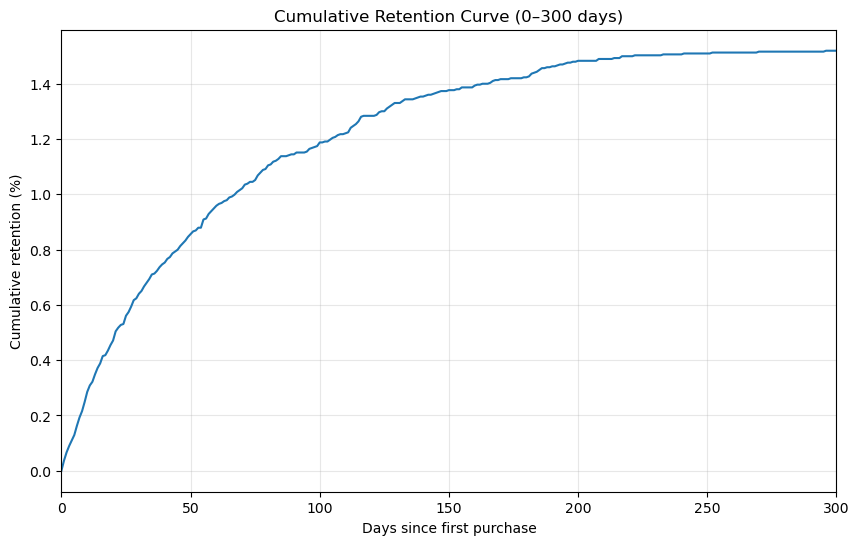

In [22]:
plot_df = retention_curve_df.copy()

plt.figure(figsize=(10, 6))
plt.plot(plot_df["day_n"], plot_df["retention_rate_pct"])

plt.xlabel("Days since first purchase")
plt.ylabel("Cumulative retention (%)")
plt.title("Cumulative Retention Curve (0–300 days)")
plt.grid(True, alpha=0.3)

plt.xlim(0, 300)
plt.show()

約 98.5% 的首購客，在 300 天內都沒有發生第二次購買。

### Cohort分析

In [23]:
# 按每月分
def build_monthly_cohort_retention_90d(df_orders, df_customers, max_day=90):
    # ========= 1) 保留必要欄位 =========
    orders = df_orders[
        ["order_id", "customer_id", "order_status", "order_purchase_timestamp"]
    ].copy()

    customers = df_customers[
        ["customer_id", "customer_unique_id"]
    ].copy()

    # ========= 2) merge + 型態處理 =========
    df = orders.merge(customers, on="customer_id", how="inner")
    df["order_purchase_timestamp"] = pd.to_datetime(
        df["order_purchase_timestamp"], errors="coerce"
    )

    # ========= 3) delivered only =========
    df = df[df["order_status"] == "delivered"].copy()
    df = df.dropna(subset=["order_purchase_timestamp", "customer_unique_id"]).copy()

    # ========= 4) 同一個 order_timestamp 壓成同一筆購買事件 =========
    df = df.sort_values(
        ["customer_unique_id", "order_purchase_timestamp", "order_id"]
    ).reset_index(drop=True)

    df_event = (
        df.drop_duplicates(
            subset=["customer_unique_id", "order_purchase_timestamp"]
        )
        .copy()
        .rename(columns={"order_purchase_timestamp": "event_ts"})
    )

    df_event = df_event[["customer_unique_id", "event_ts"]].copy()

    # ========= 5) 資料尾端截掉 90 天 =========
    data_end = df_event["event_ts"].max()
    analysis_end = data_end - pd.Timedelta(days=90)

    df_event_cut = df_event[df_event["event_ts"] <= analysis_end].copy()

    # ========= 6) 找每位顧客首購 =========
    first_purchase = (
        df_event_cut.groupby("customer_unique_id")["event_ts"]
        .min()
        .reset_index(name="first_ts")
    )

    # ========= 7) 只保留有完整 90 天觀察期的首購顧客 =========
    # 因為你要算 day 0 ~ day 90，所以首購必須 <= analysis_end - 90天
    full_window_cutoff = analysis_end - pd.Timedelta(days=max_day)

    first_purchase_eligible = first_purchase[
        first_purchase["first_ts"] <= full_window_cutoff
    ].copy()

    eligible_customers = set(first_purchase_eligible["customer_unique_id"])

    df_event_eligible = df_event_cut[
        df_event_cut["customer_unique_id"].isin(eligible_customers)
    ].copy()

    # ========= 8) merge 回首購資訊 =========
    df_cohort = df_event_eligible.merge(
        first_purchase_eligible,
        on="customer_unique_id",
        how="inner"
    )

    df_cohort["cohort_month"] = (
        df_cohort["first_ts"].dt.to_period("M").astype(str)
    )

    df_cohort["days_since_first"] = (
        df_cohort["event_ts"] - df_cohort["first_ts"]
    ).dt.days

    # ========= 9) cohort size =========
    cohort_size = (
        first_purchase_eligible.assign(
            cohort_month=first_purchase_eligible["first_ts"].dt.to_period("M").astype(str)
        )
        .groupby("cohort_month")["customer_unique_id"]
        .nunique()
        .reset_index(name="cohort_size")
    )

    # ========= 10) 只看回購事件（排除首購 day0 自己） =========
    repurchase = df_cohort[
        (df_cohort["days_since_first"] > 0) &
        (df_cohort["days_since_first"] <= max_day)
    ].copy()

    # ========= 11) 建 daily cumulative retention long table =========
    results = []

    for cohort in cohort_size["cohort_month"]:
        cohort_n = cohort_size.loc[
            cohort_size["cohort_month"] == cohort, "cohort_size"
        ].iloc[0]

        temp = repurchase[repurchase["cohort_month"] == cohort].copy()

        for day in range(0, max_day + 1):
            retained_customers = (
                temp.loc[temp["days_since_first"] <= day, "customer_unique_id"]
                .nunique()
            )

            retention_rate_pct = retained_customers / cohort_n * 100

            results.append({
                "cohort_month": cohort,
                "day_n": day,
                "cohort_size": cohort_n,
                "retained_customers": retained_customers,
                "retention_rate_pct": retention_rate_pct
            })

    cohort_retention_long = pd.DataFrame(results)

    # ========= 12) pivot table =========
    cohort_retention_pivot = cohort_retention_long.pivot(
        index="cohort_month",
        columns="day_n",
        values="retention_rate_pct"
    )

    return {
        "df_event": df_event,
        "df_event_cut": df_event_cut,
        "first_purchase_eligible": first_purchase_eligible,
        "cohort_retention_long": cohort_retention_long,
        "cohort_retention_pivot": cohort_retention_pivot,
        "cohort_size": cohort_size,
        "data_end": data_end,
        "analysis_end": analysis_end,
        "full_window_cutoff": full_window_cutoff
    }

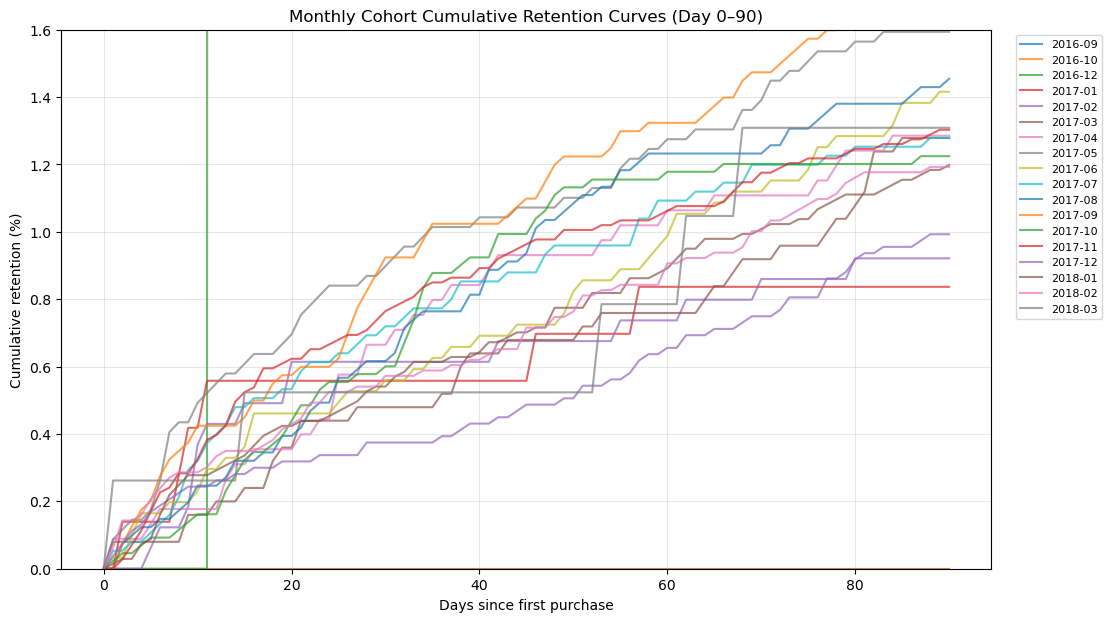

In [26]:
plt.figure(figsize=(12, 7))

for cohort in cohort_retention_long["cohort_month"].unique():
    temp = cohort_retention_long[
        cohort_retention_long["cohort_month"] == cohort
    ]

    plt.plot(
        temp["day_n"],
        temp["retention_rate_pct"],
        label=cohort,
        alpha=0.7
    )

plt.title("Monthly Cohort Cumulative Retention Curves (Day 0–90)")
plt.xlabel("Days since first purchase")
plt.ylabel("Cumulative retention (%)")
plt.grid(True, alpha=0.3)

# 重點：縮小 y 軸
plt.ylim(0, 1.6)

plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.show()

In [28]:
# 按每季分
def build_quarterly_cohort_retention_90d(df_orders, df_customers, max_day=90):
    # 1) 保留必要欄位
    orders = df_orders[
        ["order_id", "customer_id", "order_status", "order_purchase_timestamp"]
    ].copy()

    customers = df_customers[
        ["customer_id", "customer_unique_id"]
    ].copy()

    # 2) merge + 型態處理
    df = orders.merge(customers, on="customer_id", how="inner")
    df["order_purchase_timestamp"] = pd.to_datetime(
        df["order_purchase_timestamp"], errors="coerce"
    )

    # 3) delivered only
    df = df[df["order_status"] == "delivered"].copy()
    df = df.dropna(subset=["order_purchase_timestamp", "customer_unique_id"]).copy()

    # 4) 同 timestamp 壓縮成同一次購買事件
    df = df.sort_values(
        ["customer_unique_id", "order_purchase_timestamp", "order_id"]
    ).reset_index(drop=True)

    df_event = (
        df.drop_duplicates(
            subset=["customer_unique_id", "order_purchase_timestamp"]
        )
        .copy()
        .rename(columns={"order_purchase_timestamp": "event_ts"})
    )

    df_event = df_event[["customer_unique_id", "event_ts"]].copy()

    # 5) 尾端截掉 90 天
    data_end = df_event["event_ts"].max()
    analysis_end = data_end - pd.Timedelta(days=90)

    df_event_cut = df_event[df_event["event_ts"] <= analysis_end].copy()

    # 6) 每位顧客首購
    first_purchase = (
        df_event_cut.groupby("customer_unique_id")["event_ts"]
        .min()
        .reset_index(name="first_ts")
    )

    # 7) 只保留有完整 90 天觀察期的首購顧客
    full_window_cutoff = analysis_end - pd.Timedelta(days=max_day)

    first_purchase_eligible = first_purchase[
        first_purchase["first_ts"] <= full_window_cutoff
    ].copy()

    eligible_customers = set(first_purchase_eligible["customer_unique_id"])

    df_event_eligible = df_event_cut[
        df_event_cut["customer_unique_id"].isin(eligible_customers)
    ].copy()

    # 8) merge 首購資訊
    df_cohort = df_event_eligible.merge(
        first_purchase_eligible,
        on="customer_unique_id",
        how="inner"
    )

    # 改成每季 cohort
    df_cohort["cohort_quarter"] = (
        df_cohort["first_ts"].dt.to_period("Q").astype(str)
    )

    df_cohort["days_since_first"] = (
        df_cohort["event_ts"] - df_cohort["first_ts"]
    ).dt.days

    # 9) cohort size
    cohort_size = (
        first_purchase_eligible.assign(
            cohort_quarter=first_purchase_eligible["first_ts"].dt.to_period("Q").astype(str)
        )
        .groupby("cohort_quarter")["customer_unique_id"]
        .nunique()
        .reset_index(name="cohort_size")
        .sort_values("cohort_quarter")
    )

    # 10) 只看回購事件
    repurchase = df_cohort[
        (df_cohort["days_since_first"] > 0) &
        (df_cohort["days_since_first"] <= max_day)
    ].copy()

    # 11) 建 long table
    results = []

    for cohort in cohort_size["cohort_quarter"]:
        cohort_n = cohort_size.loc[
            cohort_size["cohort_quarter"] == cohort, "cohort_size"
        ].iloc[0]

        temp = repurchase[repurchase["cohort_quarter"] == cohort].copy()

        for day in range(0, max_day + 1):
            retained_customers = (
                temp.loc[temp["days_since_first"] <= day, "customer_unique_id"]
                .nunique()
            )

            retention_rate_pct = retained_customers / cohort_n * 100

            results.append({
                "cohort_quarter": cohort,
                "day_n": day,
                "cohort_size": cohort_n,
                "retained_customers": retained_customers,
                "retention_rate_pct": retention_rate_pct
            })

    cohort_retention_long = pd.DataFrame(results)

    # 12) pivot
    cohort_retention_pivot = cohort_retention_long.pivot(
        index="cohort_quarter",
        columns="day_n",
        values="retention_rate_pct"
    )

    return {
        "df_event": df_event,
        "df_event_cut": df_event_cut,
        "first_purchase_eligible": first_purchase_eligible,
        "cohort_size": cohort_size,
        "cohort_retention_long": cohort_retention_long,
        "cohort_retention_pivot": cohort_retention_pivot,
        "data_end": data_end,
        "analysis_end": analysis_end,
        "full_window_cutoff": full_window_cutoff
    }

In [29]:
quarter_result = build_quarterly_cohort_retention_90d(
    df_orders=df_orders,
    df_customers=df_customers,
    max_day=90
)

quarter_cohort_long = quarter_result["cohort_retention_long"]
quarter_cohort_pivot = quarter_result["cohort_retention_pivot"]
quarter_cohort_size = quarter_result["cohort_size"]

quarter_cohort_size
quarter_cohort_long

,cohort_quarter,day_n,cohort_size,retained_customers,retention_rate_pct
0,2016Q3,0,1,0,0.000000
1,2016Q3,1,1,0,0.000000
2,2016Q3,2,1,0,0.000000
3,2016Q3,3,1,0,0.000000
4,2016Q3,4,1,0,0.000000
...,...,...,...,...,...
632,2018Q1,86,13512,158,1.169331
633,2018Q1,87,13512,159,1.176732
634,2018Q1,88,13512,161,1.191533
635,2018Q1,89,13512,161,1.191533


In [30]:
key_days = [30, 60, 90]

quarter_key_table = (
    quarter_cohort_long[
        quarter_cohort_long["day_n"].isin(key_days)
    ]
    .pivot(index="cohort_quarter", columns="day_n", values="retention_rate_pct")
    .reset_index()
)

quarter_key_table.columns = [
    "cohort_quarter",
    "day_30_retention_pct",
    "day_60_retention_pct",
    "day_90_retention_pct"
]

quarter_key_table

,cohort_quarter,day_30_retention_pct,day_60_retention_pct,day_90_retention_pct
0,2016Q3,0.000000,0.000000,0.000000
1,2016Q4,0.380228,0.380228,0.380228
2,2017Q1,0.536304,0.763201,1.093234
3,2017Q2,0.720494,1.120769,1.452425
4,2017Q3,0.753407,1.218996,1.506815
5,2017Q4,0.597872,0.962573,1.183786
6,2018Q1,0.555062,0.895500,1.198934


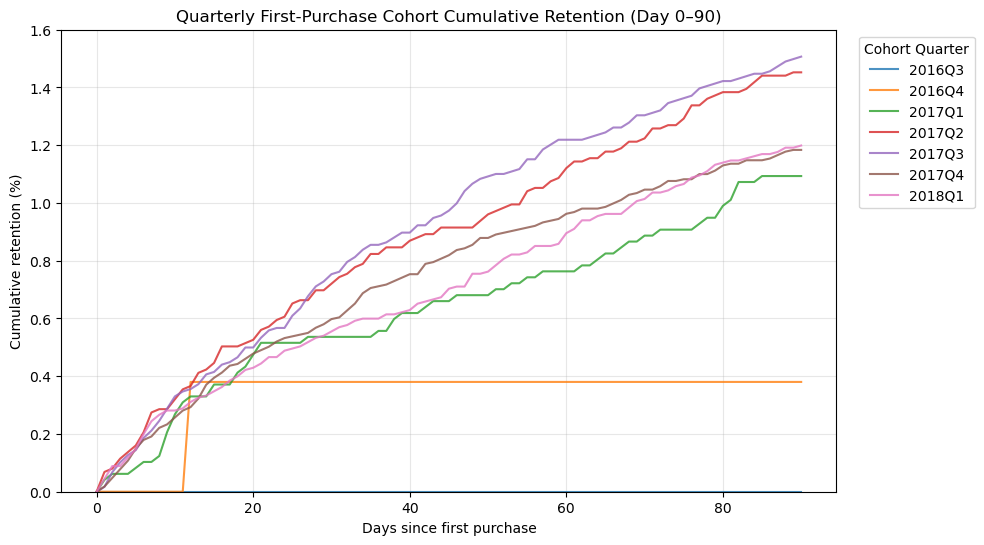

In [31]:

plt.figure(figsize=(10, 6))

for cohort in quarter_cohort_long["cohort_quarter"].unique():
    temp = quarter_cohort_long[
        quarter_cohort_long["cohort_quarter"] == cohort
    ]

    plt.plot(
        temp["day_n"],
        temp["retention_rate_pct"],
        label=cohort,
        alpha=0.8
    )

plt.title("Quarterly First-Purchase Cohort Cumulative Retention (Day 0–90)")
plt.xlabel("Days since first purchase")
plt.ylabel("Cumulative retention (%)")
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.6)  # 依你的圖形調整
plt.legend(title="Cohort Quarter", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

In [32]:
# 每月90天顧客留存率分析
monthly_retention_90d = (
    cohort_retention_long[
        cohort_retention_long["day_n"] == 90
    ]
    .copy()
    .sort_values("cohort_month")
)

monthly_retention_90d

,cohort_month,day_n,cohort_size,retained_customers,retention_rate_pct
90,2016-09,90,1,0,0.000000
181,2016-10,90,262,0,0.000000
272,2016-12,90,1,1,100.000000
363,2017-01,90,717,6,0.836820
454,2017-02,90,1628,15,0.921376
545,2017-03,90,2503,32,1.278466
636,2017-04,90,2256,29,1.285461
727,2017-05,90,3451,55,1.593741
818,2017-06,90,3037,43,1.415871
909,2017-07,90,3752,48,1.279318


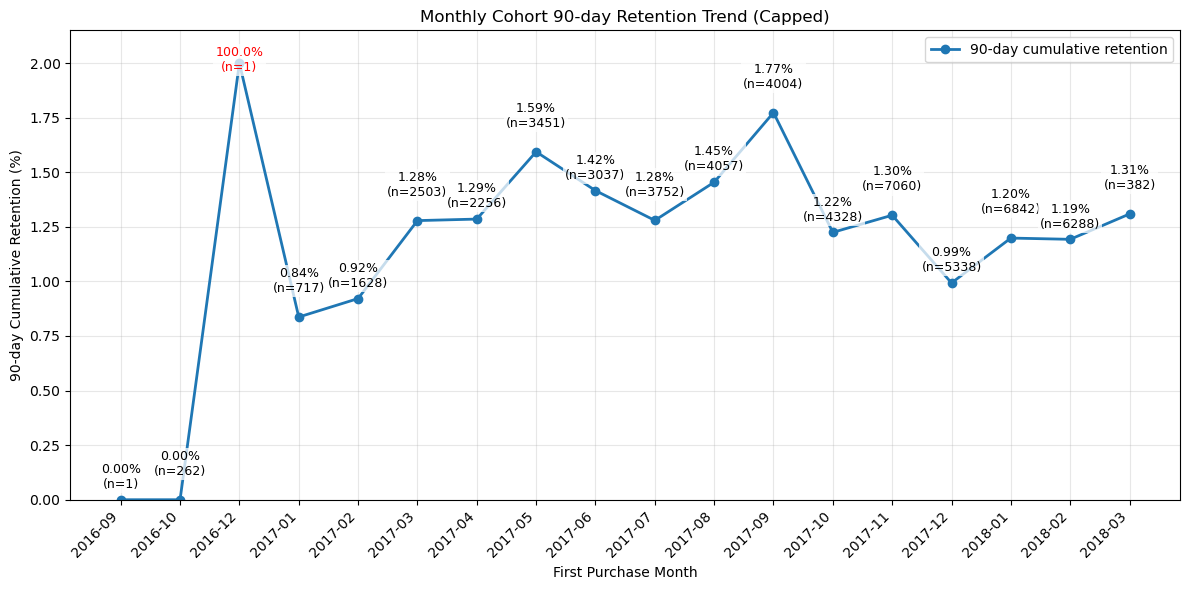

In [43]:
plt.figure(figsize=(12, 6))

# === Data ===
plot_df = monthly_retention_90d.copy().reset_index(drop=True)

x_labels = plot_df["cohort_month"]
x = np.arange(len(x_labels))

y = plot_df["retention_rate_pct"].values
sizes = plot_df["cohort_size"].values

# === y 軸上限，避免 100% outlier 拉爆圖 ===
y_cap = 2.0
y_plot = np.clip(y, 0, y_cap)

# === 主線 ===
plt.plot(
    x,
    y_plot,
    marker="o",
    linewidth=2,
    label="90-day cumulative retention"
)

# === 交錯標籤 + 白底框 ===
offsets = [0.04, 0.10]

for i in range(len(x)):
    offset = offsets[i % 2]

    if y[i] > y_cap:
        label_y = y_cap - 0.05
        label_text = f"{y[i]:.1f}%\n(n={sizes[i]})"
        color = "red"
    else:
        label_y = y_plot[i] + offset
        label_text = f"{y[i]:.2f}%\n(n={sizes[i]})"
        color = "black"

    plt.text(
        x[i],
        label_y,
        label_text,
        ha="center",
        va="bottom",
        fontsize=9,
        color=color,
        bbox=dict(
            facecolor="white",
            alpha=0.75,
            edgecolor="none",
            pad=1.5
        )
    )

# === x / y 軸 ===
plt.xticks(x, x_labels, rotation=45, ha="right")
plt.ylim(0, y_cap + 0.15)

plt.title("Monthly Cohort 90-day Retention Trend (Capped)")
plt.xlabel("First Purchase Month")
plt.ylabel("90-day Cumulative Retention (%)")

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

原始月份數: 18
過濾後月份數: 16

=== Weighted Linear Trend Result ===
                            WLS Regression Results                            
Dep. Variable:     retention_rate_pct   R-squared:                       0.016
Model:                            WLS   Adj. R-squared:                 -0.054
Method:                 Least Squares   F-statistic:                    0.2248
Date:                Sun, 03 May 2026   Prob (F-statistic):              0.643
Time:                        15:30:11   Log-Likelihood:                -1.2454
No. Observations:                  16   AIC:                             6.491
Df Residuals:                      14   BIC:                             8.036
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------

/Users/kaiping/opt/miniconda3/envs/olist/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=16 observations were given.
  return hypotest_fun_in(*args, **kwds)


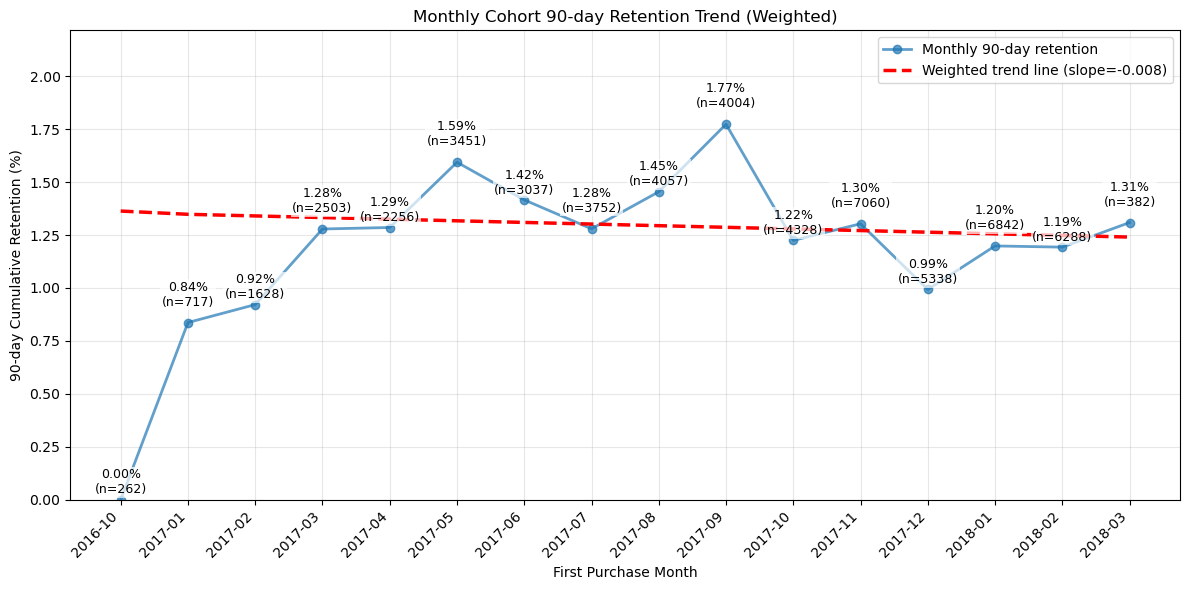

In [46]:
# 加權趨勢分析  (留存率是否隨著月份提升?)
# 計算方式(直接用每個月的留存率做 y，月份序號做 x，cohort_size 做 weight，跑加權線性回歸。)
import statsmodels.api as sm

# =========================
# 1. 準備資料
# =========================
trend_df = monthly_retention_90d.copy()

# 轉成日期，方便排序
trend_df["cohort_month_dt"] = pd.to_datetime(trend_df["cohort_month"])

trend_df = trend_df.sort_values("cohort_month_dt").reset_index(drop=True)

# 月序號（用來做趨勢回歸）
trend_df["month_index"] = np.arange(len(trend_df))

# 建議：過濾極小樣本 cohort（可依情況調整）
min_cohort_size = 100
trend_df_filtered = trend_df[trend_df["cohort_size"] >= min_cohort_size].copy()

print("原始月份數:", len(trend_df))
print("過濾後月份數:", len(trend_df_filtered))

# =========================
# 2. 加權線性趨勢回歸
# y = retention_rate_pct
# x = month_index
# weight = cohort_size
# =========================
X = sm.add_constant(trend_df_filtered["month_index"])
y = trend_df_filtered["retention_rate_pct"]
w = trend_df_filtered["cohort_size"]

wls_model = sm.WLS(y, X, weights=w).fit()

trend_df_filtered["trend_pred"] = wls_model.predict(X)

print("\n=== Weighted Linear Trend Result ===")
print(wls_model.summary())

slope = wls_model.params["month_index"]
p_value = wls_model.pvalues["month_index"]
intercept = wls_model.params["const"]

print("\n=== Key Metrics ===")
print(f"加權趨勢 slope: {slope:.4f} 個百分點 / 每月")
print(f"p-value: {p_value:.4f}")

if slope > 0:
    print("方向判讀: 留存率隨時間呈上升方向")
elif slope < 0:
    print("方向判讀: 留存率隨時間呈下降方向")
else:
    print("方向判讀: 幾乎沒有趨勢")

# =========================
# 3. 前半段 vs 後半段：加權平均留存率
# =========================
mid = len(trend_df_filtered) // 2

early_df = trend_df_filtered.iloc[:mid].copy()
late_df = trend_df_filtered.iloc[mid:].copy()

early_weighted_mean = np.average(
    early_df["retention_rate_pct"],
    weights=early_df["cohort_size"]
)

late_weighted_mean = np.average(
    late_df["retention_rate_pct"],
    weights=late_df["cohort_size"]
)

improvement = late_weighted_mean - early_weighted_mean

print("\n=== Weighted Mean Comparison ===")
print(f"前半段加權平均 90-day retention: {early_weighted_mean:.4f}%")
print(f"後半段加權平均 90-day retention: {late_weighted_mean:.4f}%")
print(f"改善幅度（後半段 - 前半段）: {improvement:.4f} 個百分點")

# =========================
# 4. 畫圖：原始點 + 加權趨勢線
# =========================
plt.figure(figsize=(12, 6))

x = np.arange(len(trend_df_filtered))
x_labels = trend_df_filtered["cohort_month"]
y_plot = trend_df_filtered["retention_rate_pct"].values
sizes = trend_df_filtered["cohort_size"].values

# 主線
plt.plot(
    x,
    y_plot,
    marker="o",
    linewidth=2,
    alpha=0.7,
    label="Monthly 90-day retention"
)

# 加權趨勢線
plt.plot(
    x,
    trend_df_filtered["trend_pred"].values,
    linestyle="--",
    linewidth=2.5,
    color="red",
    label=f"Weighted trend line (slope={slope:.3f})"
)

# 標註 cohort size
offsets = [0.03, 0.08]
for i in range(len(x)):
    offset = offsets[i % 2]
    plt.text(
        x[i],
        y_plot[i] + offset,
        f"{y_plot[i]:.2f}%\n(n={sizes[i]})",
        ha="center",
        fontsize=9,
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=1.2)
    )

plt.xticks(x, x_labels, rotation=45, ha="right")
plt.ylim(0, max(y_plot.max(), trend_df_filtered["trend_pred"].max()) * 1.25)

plt.title("Monthly Cohort 90-day Retention Trend (Weighted)")
plt.xlabel("First Purchase Month")
plt.ylabel("90-day Cumulative Retention (%)")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# 沒有證據顯示 90 天留存率有改善。 (留存率大致持平，且長期維持在很低的水位。)
# p-value = 0.6427 (這個負斜率很可能只是樣本波動，不足以證明真的存在時間下降趨勢。)
# R² = 0.016 = (月份這個變數只解釋了大約 1.6% 的留存率變異)
